# SARIMAX Model

## Objective

This notebook develops a Seasonal Autoregressive Integrated Moving Average with Exogenous Variables (SARIMAX) model to forecast weekly German electricity demand.

Weekly Berlin temperature features are incorporated as exogenous variables. Since future observed temperatures are used during forecasting, the resulting forecasts are considered **conditional (explanatory)** forecasts rather than operational forecasts.

## Load Weekly Load and Temperature Data

The weekly electricity demand dataset is combined with weekly temperature features derived from Berlin weather observations. These temperature variables are used as exogenous regressors in the SARIMAX model.

In [50]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.graphics.gofplots import qqplot

In [51]:
# Load weekly electricity demand

weekly_load = pd.read_csv(
    "weekly_load.csv",
    index_col=0,
    parse_dates=True
)

# Load weekly temperature features

weekly_temperature = pd.read_csv(
    "weekly_temperature.csv",
    index_col=0,
    parse_dates=True
)


## Align Timestamp Index

The electricity demand dataset uses UTC timestamps. The temperature dataset is converted to the same timezone before merging.

In [52]:
# Convert temperature index to UTC

weekly_temperature.index = weekly_temperature.index.tz_localize("UTC")

## Merge Electricity Demand and Temperature

The weekly electricity demand and temperature datasets are merged using their timestamp index. The temperature variables will be used as exogenous regressors in the SARIMAX model.

In [53]:
# Merge electricity demand with temperature

data = weekly_load.join(
    weekly_temperature,
    how="inner"
)

data.head()

,load,temp_mean,heating_degree,cooling_degree
timestamp,,,,
2015-01-04 00:00:00+00:00,47233.739583,2.800000,15.200000,0.0
2015-01-11 00:00:00+00:00,56191.101190,3.914286,14.085714,0.0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,13.157143,0.0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,17.942857,0.0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,16.600000,0.0


## Check the Combined Dataset

The merged dataset is inspected to ensure that electricity demand and temperature variables are available for modelling.

In [54]:
print(data.info())

print(data.isna().sum())

data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 301 entries, 2015-01-04 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   load            301 non-null    float64
 1   temp_mean       301 non-null    float64
 2   heating_degree  301 non-null    float64
 3   cooling_degree  301 non-null    float64
dtypes: float64(4)
memory usage: 11.8 KB
None
load              0
temp_mean         0
heating_degree    0
cooling_degree    0
dtype: int64


,load,temp_mean,heating_degree,cooling_degree
timestamp,,,,
2015-01-04 00:00:00+00:00,47233.739583,2.800000,15.200000,0.0
2015-01-11 00:00:00+00:00,56191.101190,3.914286,14.085714,0.0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,13.157143,0.0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,17.942857,0.0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,16.600000,0.0


In [55]:
forecast_horizon = 104

train = data.iloc[:-forecast_horizon]
test = data.iloc[-forecast_horizon:]

## Prepare Endogenous and Exogenous Variables

Electricity demand is used as the endogenous variable.

Weekly temperature, heating degree days and cooling degree days are included as exogenous regressors.

In [56]:
y_train = train["load"]
y_test = test["load"]

X_train = train[
    [
        "temp_mean",
        "heating_degree",
        "cooling_degree"
    ]
]

X_test = test[
    [
        "temp_mean",
        "heating_degree",
        "cooling_degree"
    ]
]

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,2),
    seasonal_order=(0,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit()

In [57]:
print(sarimax_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 52)   Log Likelihood                -769.033
Date:                              Fri, 03 Jul 2026   AIC                           1554.066
Time:                                      13:59:37   BIC                           1573.975
Sample:                                  01-04-2015   HQIC                          1562.091
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
temp_mean         -9.7539   7163.148     -0.001      0.999    -1.4e+04     1.4e+04
heating

In [58]:
with open("sarimax_model_summary.txt", "w") as f:
    f.write(sarimax_results.summary().as_text())

## Generate Forecasts

Forecasts are generated for the test period using the observed temperature features. This represents a conditional forecast because future temperature observations are assumed to be known.

In [59]:
forecast = sarimax_results.get_forecast(

    steps=len(test),

    exog=X_test

)

forecast_mean = forecast.predicted_mean

forecast_confidence = forecast.conf_int()

## Residual Diagnostics

Residual diagnostics are performed to determine whether the fitted SARIMAX model adequately captures the temporal structure of the data. Ideally, the residuals should be randomly distributed around zero with no remaining autocorrelation.

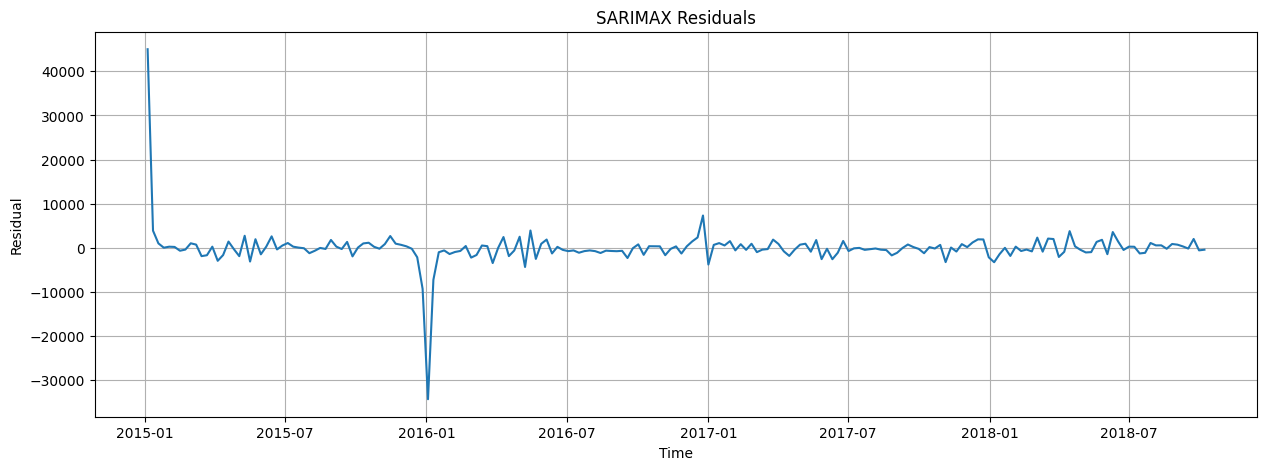

In [60]:
# Calculate residuals

residuals = sarimax_results.resid

# Plot residuals

plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMAX Residuals")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.grid(True)

plt.savefig(
    "sarimax_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

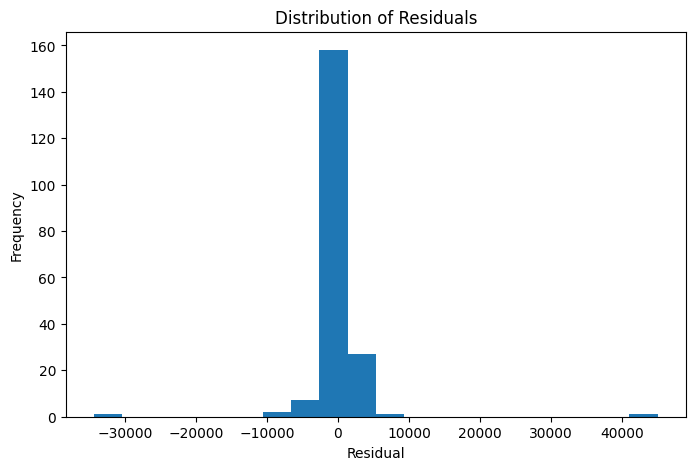

In [61]:
# Plot residual distribution

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=20
)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.savefig(
    "sarimax_residual_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

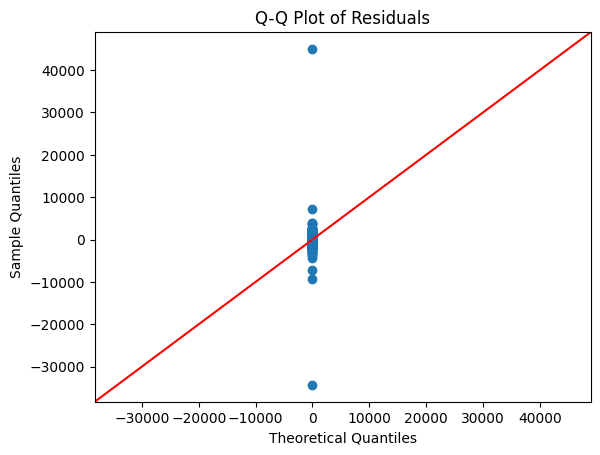

In [62]:
# Q-Q plot

qqplot(
    residuals,
    line="45"
)

plt.title("Q-Q Plot of Residuals")

plt.savefig(
    "sarimax_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Ljung–Box Test

The Ljung–Box test is applied to determine whether significant autocorrelation remains in the model residuals. A p-value greater than 0.05 indicates that the residuals behave like white noise.

In [63]:
# Perform Ljung–Box test

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
10,9.035473,0.52874


## SARIMAX Forecasting

The fitted SARIMAX model is used to generate forecasts for the testing period. Forecasted values are compared with the observed electricity demand to assess predictive performance.

In [64]:
# Generate forecasts for the testing period

sarimax_forecast = sarimax_results.get_forecast(
    steps=len(test),
    exog=X_test
)

forecast_mean = sarimax_forecast.predicted_mean
forecast_ci = sarimax_forecast.conf_int()

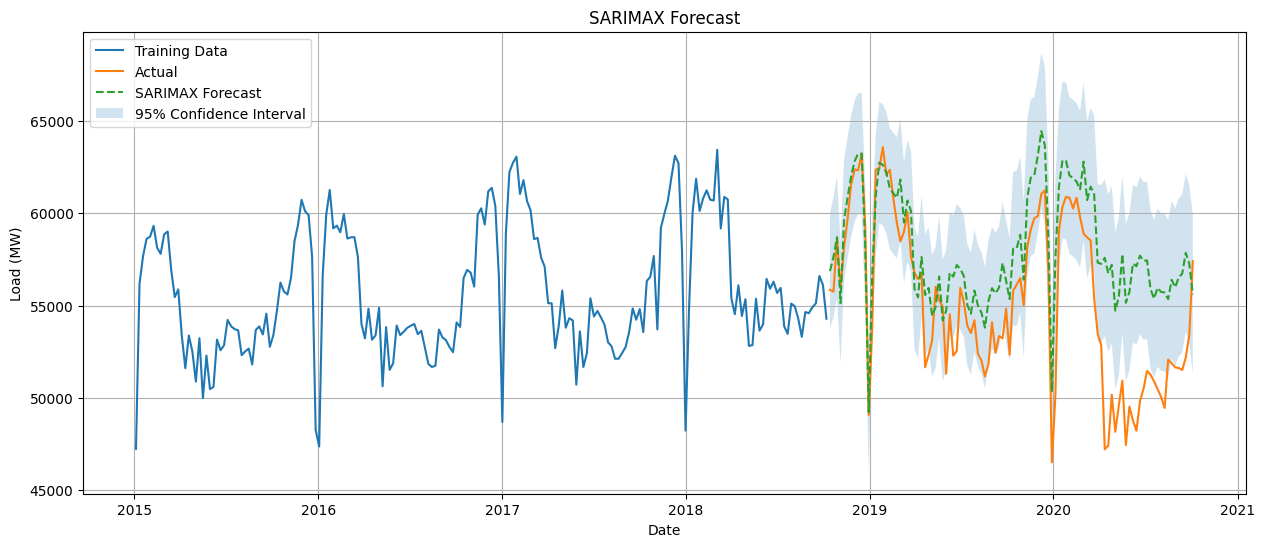

In [65]:
# Plot forecasts

plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual"
)

plt.plot(
    test.index,
    forecast_mean,
    linestyle="--",
    label="SARIMAX Forecast"
)

plt.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast")

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.grid(True)

plt.savefig(
    "sarimax_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation Function

A reusable evaluation function is defined to calculate three forecasting accuracy metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE). These metrics are used consistently across all forecasting models in this project.

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Forecast evaluation function

def evaluate_forecast(actual, forecast):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## Forecast Evaluation

Forecast accuracy is evaluated using three commonly used error metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

These metrics are compared with the benchmark and SARIMA models.

In [67]:
sarimax_metrics = evaluate_forecast(
    test["load"],
    forecast_mean
)

print(sarimax_metrics)

{'RMSE': np.float64(3851.1430632990305), 'MAE': 3069.8939958185665, 'MAPE': np.float64(5.857532168725118)}


In [68]:
sarimax_metrics_df = pd.DataFrame(
    [sarimax_metrics]
)

sarimax_metrics_df.to_csv(
    "sarimax_metrics.csv",
    index=False
)

sarimax_metrics_df

,RMSE,MAE,MAPE
0,3851.143063,3069.893996,5.857532


In [69]:
forecast_df = pd.DataFrame({
    "Actual": test["load"],
    "Forecast": forecast_mean
})

forecast_df.to_csv(
    "sarimax_forecast.csv"
)

forecast_df.head()

,Actual,Forecast
2018-10-14 00:00:00+00:00,55848.940476,56867.881720
2018-10-21 00:00:00+00:00,55762.125000,57632.714470
2018-10-28 00:00:00+00:00,58684.714286,58702.664522
2018-11-04 00:00:00+00:00,55917.589286,55136.427901
2018-11-11 00:00:00+00:00,58163.470238,59635.056962


## Forecast Evaluation

The SARIMAX model incorporating weekly temperature features achieved a slight improvement over the baseline SARIMA model.

All three evaluation metrics (RMSE, MAE and MAPE) decreased, indicating that the inclusion of temperature provided additional explanatory information for forecasting weekly electricity demand.

Because observed future temperature values were supplied during forecasting, these results represent a **conditional (explanatory)** forecast rather than a true operational forecast.